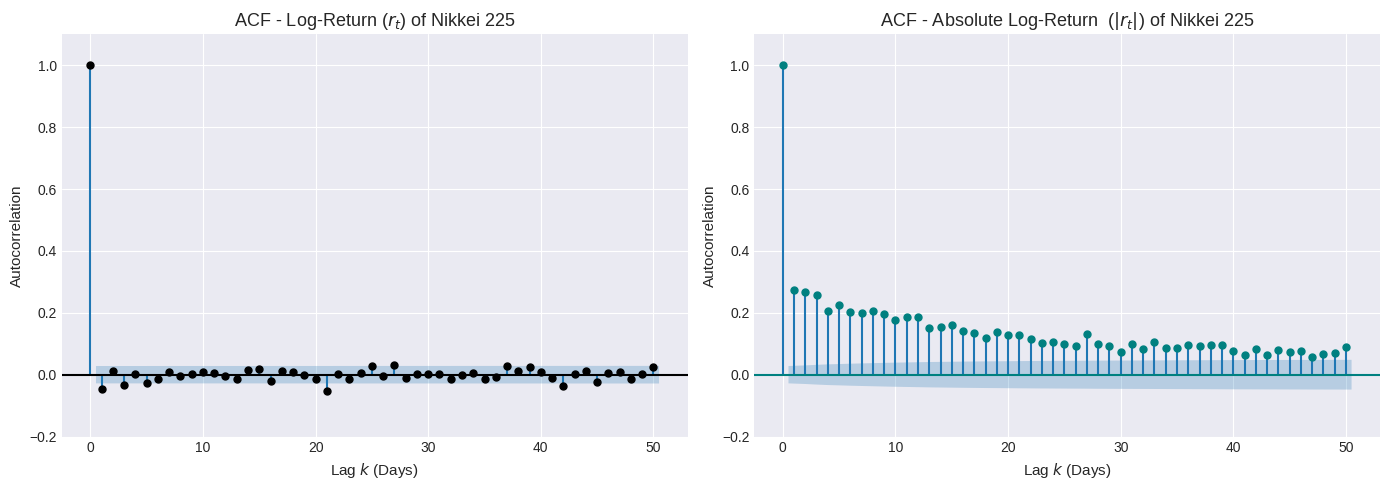

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

# Impostazione stile
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Caricamento Dati Nikkei 225
csv_path = "/content/^nkx_d-2.csv"
df = pd.read_csv(csv_path)

# Converti la colonna Date come indice se presente
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# 2. Calcolo Log-Rendimenti
log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()

# 3. Creazione Grafici ACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ACF Rendimenti Grezzi
plot_acf(log_ret, lags=50, ax=ax1, color='black', alpha=0.05)
ax1.set_title("ACF - Log-Return ($r_t$) of Nikkei 225", fontsize=13)
ax1.set_xlabel("Lag $k$ (Days)", fontsize=11)
ax1.set_ylabel("Autocorrelation", fontsize=11)
ax1.set_ylim(-0.2, 1.1)

# ACF Rendimenti Assoluti
plot_acf(log_ret.abs(), lags=50, ax=ax2, color='teal', alpha=0.05)
ax2.set_title("ACF - Absolute Log-Return  ($|r_t|$) of Nikkei 225", fontsize=13)
ax2.set_xlabel("Lag $k$ (Days)", fontsize=11)
ax2.set_ylabel("Autocorrelation", fontsize=11)
ax2.set_ylim(-0.2, 1.1)

plt.tight_layout()
plt.savefig("acf_nikkei225.png", dpi=150)
plt.show()

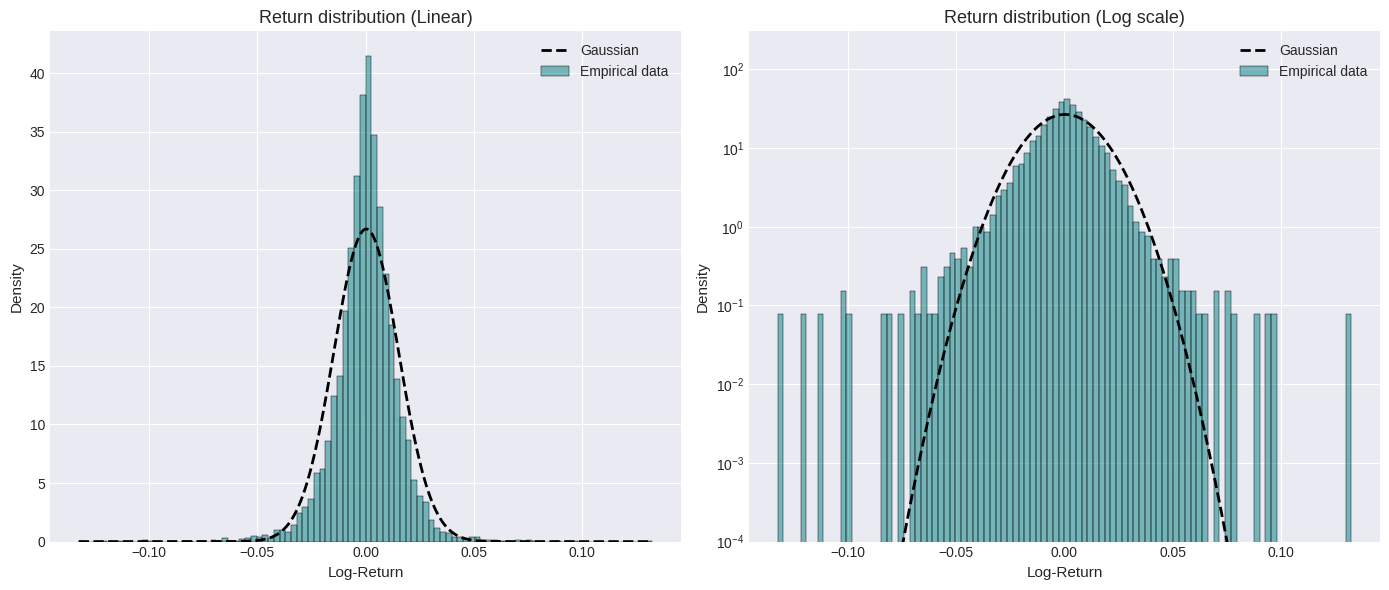

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# Impostazione stile
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Caricamento Dati (es. Nikkei 225)
csv_path = "/content/^nkx_d-2.csv"
df = pd.read_csv(csv_path)

# Calcolo Log-Rendimenti
log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()

# Fit della distribuzione Normale per confronto
mu, std = norm.fit(log_ret)

# 2. Creazione Grafici
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x_asse = np.linspace(log_ret.min(), log_ret.max(), 1000)
pdf_normale = norm.pdf(x_asse, mu, std)

# --- Pannello 1: Scala Lineare (Il focus sul "Bulk") ---
sns.histplot(log_ret, bins=100, stat='density', ax=ax1, color='teal', alpha=0.5, label='Empirical data')
ax1.plot(x_asse, pdf_normale, color='black', linewidth=2, linestyle='--', label='Gaussian')

ax1.set_title("Return distribution (Linear)", fontsize=13)
ax1.set_xlabel("Log-Return", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)
ax1.legend()

# --- Pannello 2: Scala Semi-Logaritmica (Il focus sulle "Fat Tails") ---
sns.histplot(log_ret, bins=100, stat='density', ax=ax2, color='teal', alpha=0.5, label='Empirical data')
ax2.plot(x_asse, pdf_normale, color='black', linewidth=2, linestyle='--', label='Gaussian')

ax2.set_yscale('log') # IL PASSAGGIO CHIAVE
ax2.set_ylim(bottom=1e-4) # Taglia il rumore inferiore per pulizia visiva

ax2.set_title("Return distribution (Log scale)", fontsize=13)
ax2.set_xlabel("Log-Return", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.legend()

plt.tight_layout()
plt.savefig("distribuzione_code_pesanti.png", dpi=150)
plt.show()

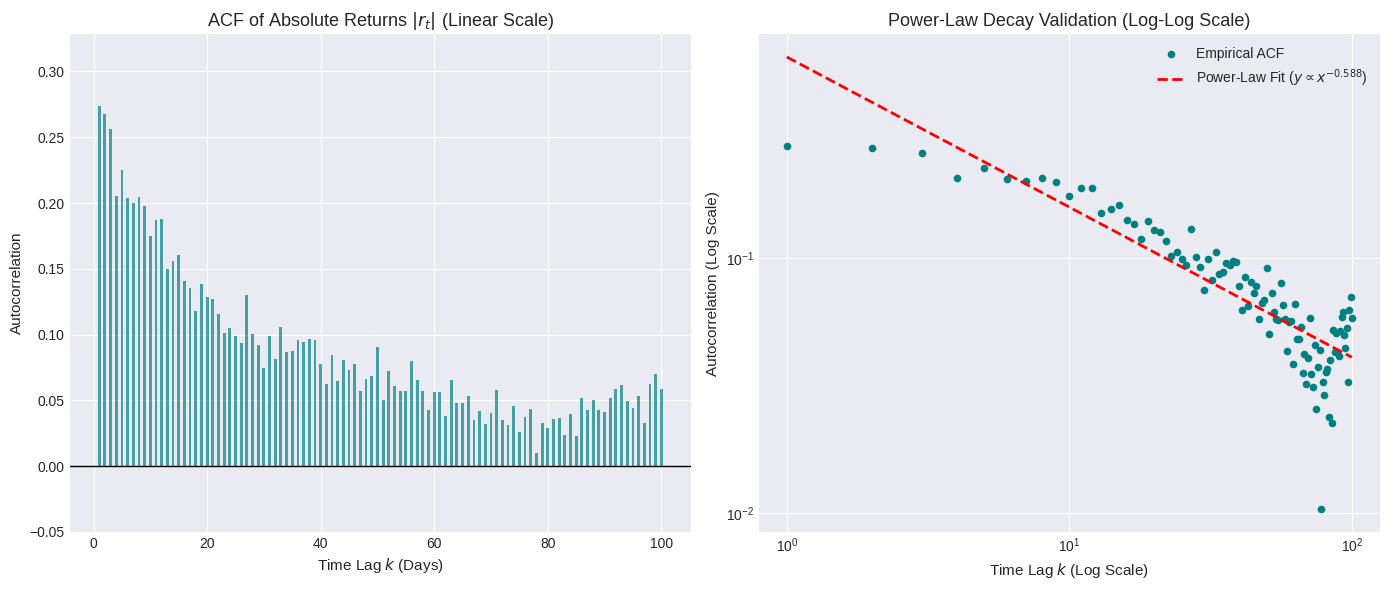

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Load Data (e.g., Nikkei 225)
csv_path = "/content/^nkx_d-2.csv"
df = pd.read_csv(csv_path)

# Calculate Absolute Log-Returns
log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()
abs_ret = np.abs(log_ret)

# 2. Compute Autocorrelation for long lags (k = 100)
max_lags = 100
# acf() returns lag 0 at index 0 (which is 1.0). We slice [1:] to get lags 1 to 100.
acf_values = acf(abs_ret, nlags=max_lags, fft=True)[1:]
lags = np.arange(1, max_lags + 1)

# 3. Fit Power-Law: log(ACF) = -beta * log(k) + c
# We only use positive ACF values to safely compute logarithms
valid_idx = acf_values > 0
log_k = np.log(lags[valid_idx])
log_acf = np.log(acf_values[valid_idx])

slope, intercept, r_value, p_value, std_err = linregress(log_k, log_acf)
beta = -slope  # Since the formula is k^(-beta)

# 4. Create Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Linear Scale (Long-range dependence) ---
ax1.bar(lags, acf_values, width=0.5, color='teal', alpha=0.7)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_title("ACF of Absolute Returns $|r_t|$ (Linear Scale)", fontsize=13)
ax1.set_xlabel("Time Lag $k$ (Days)", fontsize=11)
ax1.set_ylabel("Autocorrelation", fontsize=11)
ax1.set_ylim(-0.05, max(acf_values) * 1.2)

# --- Panel 2: Log-Log Scale (Power-law validation) ---
ax2.scatter(lags[valid_idx], acf_values[valid_idx], color='teal', s=20, label='Empirical ACF')

# Plot the fitted regression line in the log-log space
fit_line = np.exp(intercept) * (lags ** slope)
ax2.plot(lags, fit_line, color='red', linestyle='--', linewidth=2,
         label=f'Power-Law Fit ($y \propto x^{{-{beta:.3f}}}$)')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title("Power-Law Decay Validation (Log-Log Scale)", fontsize=13)
ax2.set_xlabel("Time Lag $k$ (Log Scale)", fontsize=11)
ax2.set_ylabel("Autocorrelation (Log Scale)", fontsize=11)
ax2.legend()

plt.tight_layout()
plt.savefig("volatility_clustering_powerlaw.png", dpi=150)
plt.show()

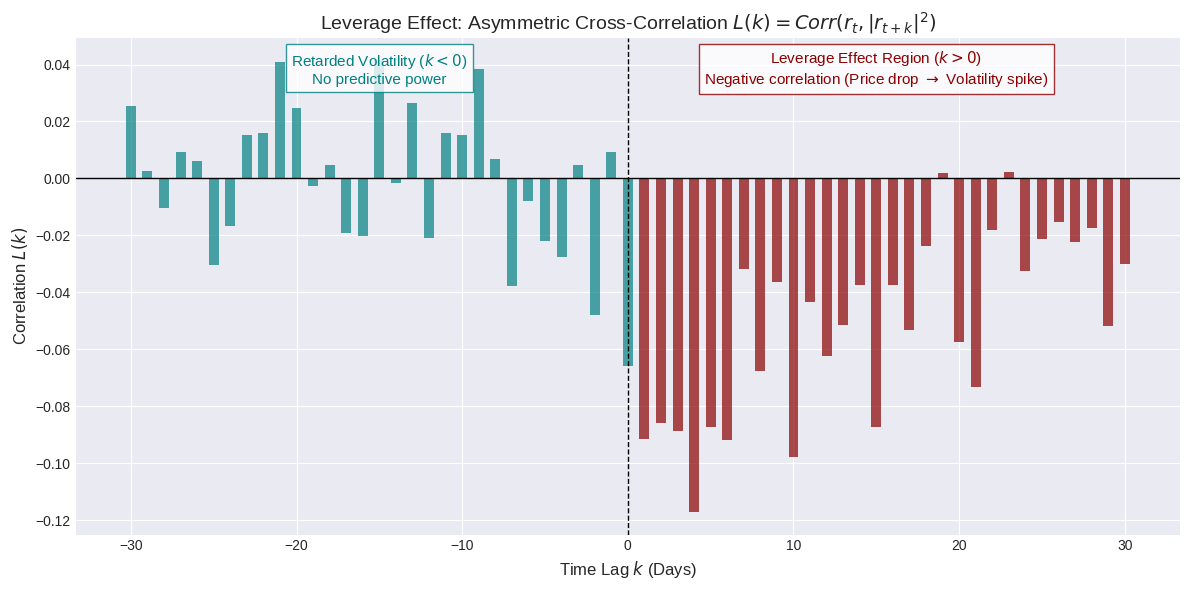

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Impostazione stile
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Caricamento Dati (Usiamo il Nasdaq o l'S&P500 come mercato occidentale)
csv_path = "/content/^ndx_d copia.csv"
df = pd.read_csv(csv_path)

# Calcolo dei Log-Rendimenti
log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna().values

# Proxy della volatilità (rendimenti al quadrato, come indicato nella formula della tesi)
volatility = log_ret**2

# 2. Calcolo della Cross-Correlazione L(k)
max_lag = 30
lags = np.arange(-max_lag, max_lag + 1)
L_k = []

for k in lags:
    if k < 0:
        # Lag negativi (k < 0): Correlazione tra rendimenti futuri e volatilità passata
        corr = np.corrcoef(log_ret[-k:], volatility[:k])[0, 1]
    elif k > 0:
        # Lag positivi (k > 0): Correlazione tra rendimenti passati e volatilità futura
        corr = np.corrcoef(log_ret[:-k], volatility[k:])[0, 1]
    else:
        # Lag 0
        corr = np.corrcoef(log_ret, volatility)[0, 1]
    L_k.append(corr)

# 3. Creazione del Grafico
fig, ax = plt.subplots(figsize=(12, 6))

# Creiamo un array di colori: grigio/teal per k <= 0, rosso per k > 0 per evidenziare il fenomeno
colori = ['teal' if k <= 0 else 'darkred' for k in lags]

# Bar plot della cross-correlazione
ax.bar(lags, L_k, color=colori, alpha=0.7, width=0.6)

# Assi di riferimento
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1, linestyle='--')

# Formattazione
ax.set_title("Leverage Effect: Asymmetric Cross-Correlation $L(k) = Corr(r_t, |r_{t+k}|^2)$", fontsize=14)
ax.set_xlabel("Time Lag $k$ (Days)", fontsize=12)
ax.set_ylabel("Correlation $L(k)$", fontsize=12)

# Annotazioni per la tesi
ax.text(15, max(L_k)*0.8, 'Leverage Effect Region ($k > 0$)\nNegative correlation (Price drop $\\rightarrow$ Volatility spike)',
        color='darkred', fontsize=11, ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='darkred'))

ax.text(-15, max(L_k)*0.8, 'Retarded Volatility ($k < 0$)\nNo predictive power',
        color='teal', fontsize=11, ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='teal'))

plt.tight_layout()
plt.savefig("leverage_effect.png", dpi=150)
plt.show()

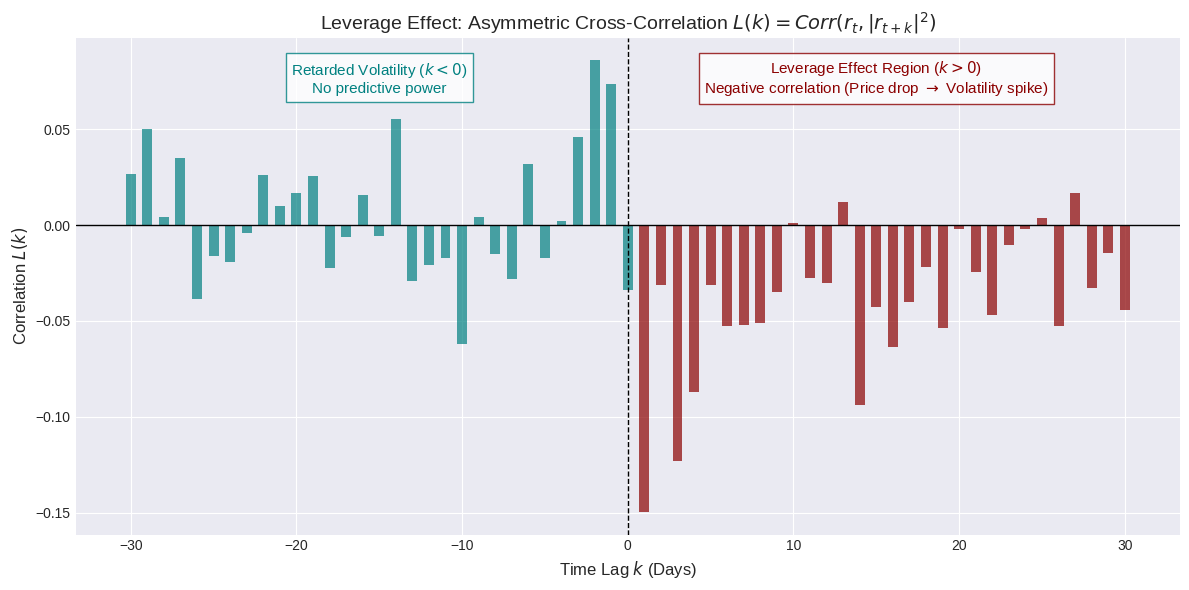

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Impostazione stile
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Caricamento Dati (Usiamo il Nasdaq o l'S&P500 come mercato occidentale)
csv_path = "/content/^hsi_d.csv"
df = pd.read_csv(csv_path)

# Calcolo dei Log-Rendimenti
log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna().values

# Proxy della volatilità (rendimenti al quadrato, come indicato nella formula della tesi)
volatility = log_ret**2

# 2. Calcolo della Cross-Correlazione L(k)
max_lag = 30
lags = np.arange(-max_lag, max_lag + 1)
L_k = []

for k in lags:
    if k < 0:
        # Lag negativi (k < 0): Correlazione tra rendimenti futuri e volatilità passata
        corr = np.corrcoef(log_ret[-k:], volatility[:k])[0, 1]
    elif k > 0:
        # Lag positivi (k > 0): Correlazione tra rendimenti passati e volatilità futura
        corr = np.corrcoef(log_ret[:-k], volatility[k:])[0, 1]
    else:
        # Lag 0
        corr = np.corrcoef(log_ret, volatility)[0, 1]
    L_k.append(corr)

# 3. Creazione del Grafico
fig, ax = plt.subplots(figsize=(12, 6))

# Creiamo un array di colori: grigio/teal per k <= 0, rosso per k > 0 per evidenziare il fenomeno
colori = ['teal' if k <= 0 else 'darkred' for k in lags]

# Bar plot della cross-correlazione
ax.bar(lags, L_k, color=colori, alpha=0.7, width=0.6)

# Assi di riferimento
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1, linestyle='--')

# Formattazione
ax.set_title("Leverage Effect: Asymmetric Cross-Correlation $L(k) = Corr(r_t, |r_{t+k}|^2)$", fontsize=14)
ax.set_xlabel("Time Lag $k$ (Days)", fontsize=12)
ax.set_ylabel("Correlation $L(k)$", fontsize=12)

# Annotazioni per la tesi
ax.text(15, max(L_k)*0.8, 'Leverage Effect Region ($k > 0$)\nNegative correlation (Price drop $\\rightarrow$ Volatility spike)',
        color='darkred', fontsize=11, ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='darkred'))

ax.text(-15, max(L_k)*0.8, 'Retarded Volatility ($k < 0$)\nNo predictive power',
        color='teal', fontsize=11, ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='teal'))

plt.tight_layout()
plt.savefig("leverage_effect.png", dpi=150)
plt.show()

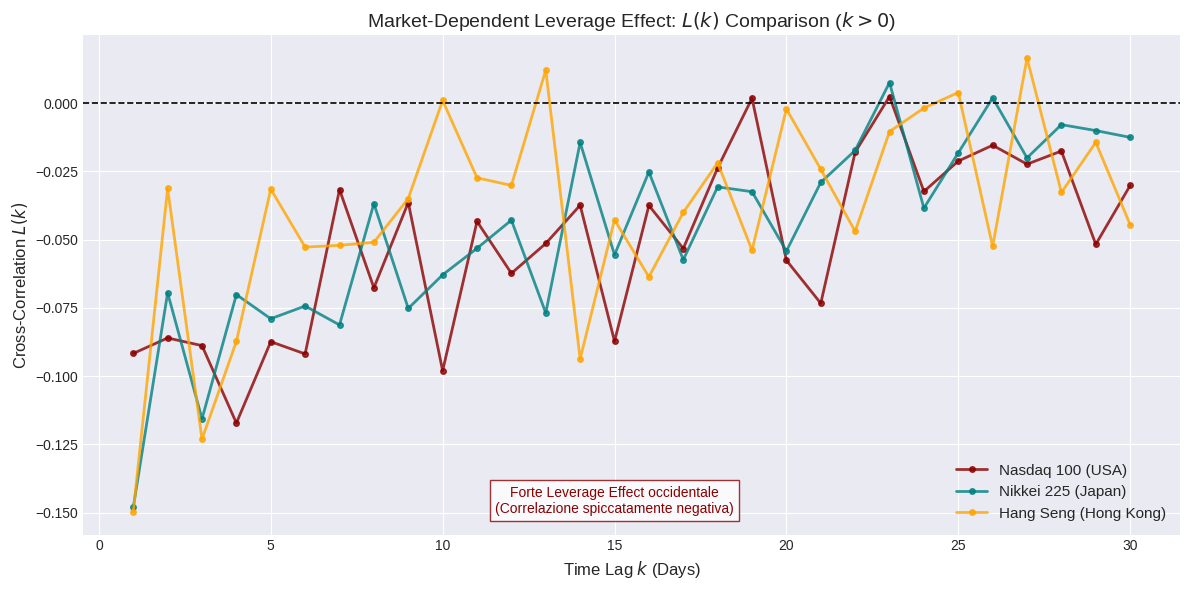

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Impostazione stile
plt.style.use('seaborn-v0_8-darkgrid')

def calcola_leverage_positivo(percorso_csv, max_lag=30):
    """Calcola la cross-correlazione solo per k > 0 (Leverage Effect puro)"""
    try:
        df = pd.read_csv(percorso_csv)
        log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna().values
        volatility = log_ret**2

        L_k = []
        lags = np.arange(1, max_lag + 1)

        for k in lags:
            # Correlazione tra rendimenti al tempo t e volatilità al tempo t+k
            corr = np.corrcoef(log_ret[:-k], volatility[k:])[0, 1]
            L_k.append(corr)

        return lags, L_k
    except Exception as e:
        print(f"Errore nella lettura di {percorso_csv}: {e}")
        return None, None

# 1. Definizione degli asset da confrontare
asset_files = {
    "Nasdaq 100 (USA)": "/content/^ndx_d copia.csv",
    "Nikkei 225 (Japan)": "/content/^nkx_d-2.csv",
    "Hang Seng (Hong Kong)": "/content/^hsi_d.csv"
}

colori = {
    "Nasdaq 100 (USA)": "darkred",
    "Nikkei 225 (Japan)": "teal",
    "Hang Seng (Hong Kong)": "orange"
}

# 2. Creazione del Grafico Comparativo
fig, ax = plt.subplots(figsize=(12, 6))

for nome, percorso in asset_files.items():
    lags, L_k = calcola_leverage_positivo(percorso)
    if lags is not None:
        ax.plot(lags, L_k, marker='o', markersize=4, linewidth=2,
                color=colori[nome], alpha=0.8, label=nome)

# Assi di riferimento
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')

# Formattazione
ax.set_title("Market-Dependent Leverage Effect: $L(k)$ Comparison ($k > 0$)", fontsize=14)
ax.set_xlabel("Time Lag $k$ (Days)", fontsize=12)
ax.set_ylabel("Cross-Correlation $L(k)$", fontsize=12)
ax.legend(fontsize=11)

# Annotazione
ax.text(15, -0.15, 'Forte Leverage Effect occidentale\n(Correlazione spiccatamente negativa)',
        color='darkred', fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='darkred'))

plt.tight_layout()
plt.savefig("confronto_leverage_mercati.png", dpi=150)
plt.show()

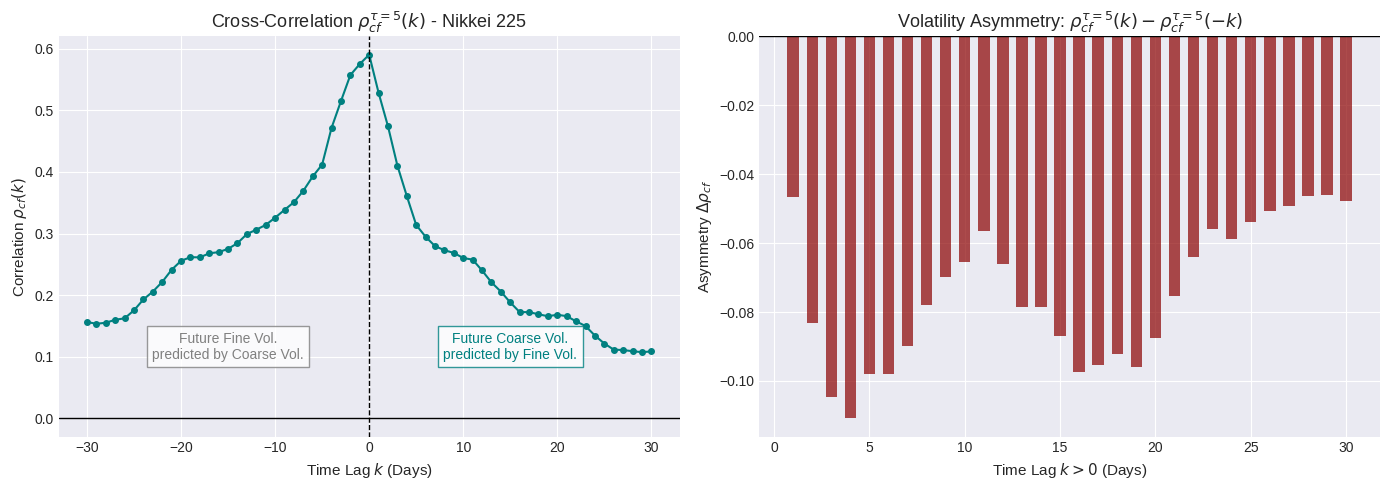

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Impostazione stile
plt.style.use('seaborn-v0_8-darkgrid')

def analizza_asimmetria_volatilita(percorso_csv, tau=5, max_lag=30, asset_name="S&P 500"):
    # 1. Caricamento Dati e calcolo log-rendimenti
    df = pd.read_csv(percorso_csv)
    log_ret = np.log(df['Close'] / df['Close'].shift(1)).dropna()

    # 2. Calcolo Fine e Coarse Volatility (Finestra tau)
    # Coarse Volatility: |somma dei rendimenti su tau giorni|
    v_c = log_ret.rolling(window=tau).sum().abs().dropna()

    # Fine Volatility: somma dei |rendimenti| su tau giorni
    v_f = log_ret.abs().rolling(window=tau).sum().dropna()

    # Allineamento indici
    common_idx = v_c.index.intersection(v_f.index)
    v_c = v_c.loc[common_idx]
    v_f = v_f.loc[common_idx]

    # 3. Calcolo Cross-Correlazione p_cf(k)
    lags = np.arange(-max_lag, max_lag + 1)
    rho_cf = []

    for k in lags:
        # Corr( v_c(t+k), v_f(t) )
        # Shift negativo (-k) trasla v_c all'indietro per allineare il futuro di v_c col presente di v_f
        corr = v_c.shift(-k).corr(v_f)
        rho_cf.append(corr)

    rho_cf = np.array(rho_cf)

    # 4. Calcolo Asimmetria: p_cf(k) - p_cf(-k) per k > 0
    lags_pos = np.arange(1, max_lag + 1)
    asimmetria = []

    for k in lags_pos:
        idx_pos = np.where(lags == k)[0][0]
        idx_neg = np.where(lags == -k)[0][0]
        asimmetria.append(rho_cf[idx_pos] - rho_cf[idx_neg])

    # 5. Creazione Grafici
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Pannello 1: Cross-Correlazione ---
    ax1.plot(lags, rho_cf, marker='o', markersize=4, color='teal', linewidth=1.5)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.axhline(0, color='black', linewidth=1)

    ax1.set_title(rf"Cross-Correlation $\rho_{{cf}}^{{\tau={tau}}}(k)$ - {asset_name}", fontsize=13)
    ax1.set_xlabel("Time Lag $k$ (Days)", fontsize=11)
    ax1.set_ylabel(r"Correlation $\rho_{cf}(k)$", fontsize=11)

    # Annotazioni Pannello 1
    ax1.text(15, min(rho_cf)*0.9, 'Future Coarse Vol.\npredicted by Fine Vol.',
             color='teal', ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='teal'))
    ax1.text(-15, min(rho_cf)*0.9, 'Future Fine Vol.\npredicted by Coarse Vol.',
             color='gray', ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # --- Pannello 2: Asimmetria ---
    ax2.bar(lags_pos, asimmetria, color='darkred', alpha=0.7, width=0.6)
    ax2.axhline(0, color='black', linewidth=1)

    ax2.set_title(rf"Volatility Asymmetry: $\rho_{{cf}}^{{\tau={tau}}}(k) - \rho_{{cf}}^{{\tau={tau}}}(-k)$", fontsize=13)
    ax2.set_xlabel("Time Lag $k > 0$ (Days)", fontsize=11)
    ax2.set_ylabel(r"Asymmetry $\Delta \rho_{cf}$", fontsize=11)

    plt.tight_layout()
    plt.savefig("volatility_asymmetry.png", dpi=150)
    plt.show()

# Esecuzione (inserisci il percorso del tuo CSV, es. Nasdaq)
if __name__ == "__main__":
    CSV_PATH = "/content/^nkx_d-2.csv"
    analizza_asimmetria_volatilita(CSV_PATH, tau=5, max_lag=30, asset_name="Nikkei 225")

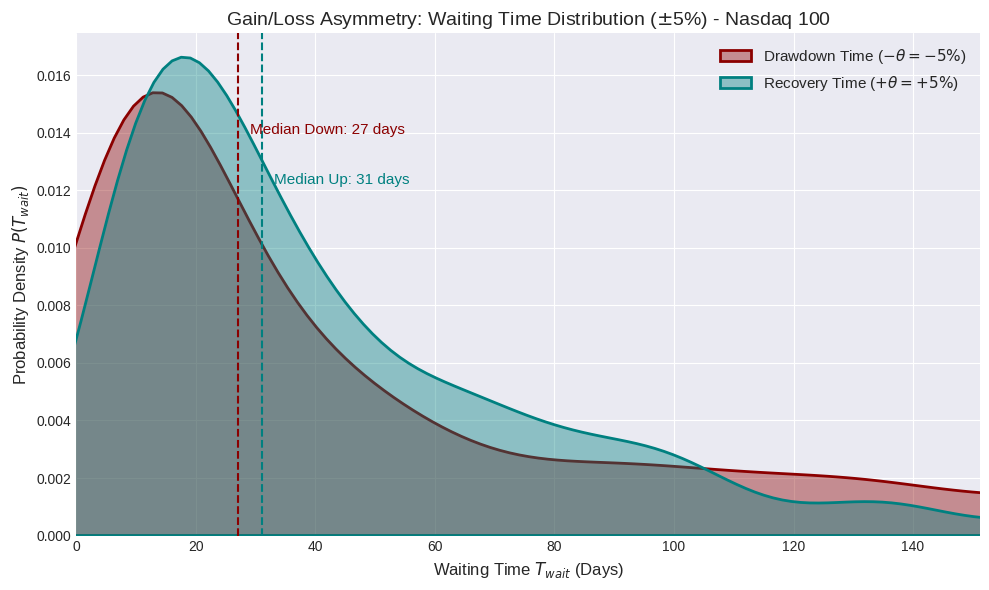

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Impostazione stile
plt.style.use('seaborn-v0_8-darkgrid')

def analizza_asimmetria_attesa(percorso_csv, theta=0.05, max_horizon=252, asset_name="Asset"):
    """
    Calcola e plotta la Gain/Loss Asymmetry basata sui tempi di attesa (Waiting Times).
    theta: Soglia di rendimento cumulativo (es. 0.05 per 5%)
    max_horizon: Orizzonte temporale massimo di ricerca in giorni
    """
    # 1. Caricamento Dati
    df = pd.read_csv(percorso_csv)
    log_prices = np.log(df['Close'].values)

    n = len(log_prices)
    t_up = []
    t_down = []

    # 2. Calcolo dei Waiting Times con operatore infimum
    for t in range(n - 1):
        end_idx = min(t + max_horizon + 1, n)
        # Log-rendimento cumulativo rispetto al tempo t
        cum_ret = log_prices[t+1:end_idx] - log_prices[t]

        # Infimum per +theta (Gain)
        up_idx = np.where(cum_ret >= theta)[0]
        if len(up_idx) > 0:
            t_up.append(up_idx[0] + 1)

        # Infimum per -theta (Loss)
        down_idx = np.where(cum_ret <= -theta)[0]
        if len(down_idx) > 0:
            t_down.append(down_idx[0] + 1)

    t_up = np.array(t_up)
    t_down = np.array(t_down)

    # 3. Statistiche Descrittive (Mediane)
    mediana_up = np.median(t_up)
    mediana_down = np.median(t_down)

    # 4. Creazione Grafico
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot KDE (Densità di Probabilità)
    sns.kdeplot(t_down, color='darkred', fill=True, alpha=0.4, linewidth=2,
                label=rf'Drawdown Time ($-\theta = -{theta*100:.0f}\%$)')
    sns.kdeplot(t_up, color='teal', fill=True, alpha=0.4, linewidth=2,
                label=rf'Recovery Time ($+\theta = +{theta*100:.0f}\%$)')

    # Linee per le Mediane
    ax.axvline(mediana_down, color='darkred', linestyle='--', linewidth=1.5)
    ax.axvline(mediana_up, color='teal', linestyle='--', linewidth=1.5)

    # Formattazione
    ax.set_title(f"Gain/Loss Asymmetry: Waiting Time Distribution ($\pm${theta*100:.0f}%) - {asset_name}", fontsize=14)
    ax.set_xlabel(r"Waiting Time $T_{wait}$ (Days)", fontsize=12)
    ax.set_ylabel("Probability Density $P(T_{wait})$", fontsize=12)
    ax.set_xlim(0, max_horizon * 0.6) # Zoom sulla parte rilevante della distribuzione
    ax.legend(fontsize=11)

    # Annotazioni
    ax.text(mediana_down + 2, ax.get_ylim()[1]*0.8, f'Median Down: {mediana_down:.0f} days', color='darkred', fontsize=11)
    ax.text(mediana_up + 2, ax.get_ylim()[1]*0.7, f'Median Up: {mediana_up:.0f} days', color='teal', fontsize=11)

    plt.tight_layout()
    plt.savefig("gain_loss_asymmetry.png", dpi=150)
    plt.show()

# Esecuzione (inserisci il percorso del tuo CSV)
if __name__ == "__main__":
    CSV_PATH = "/content/^ndx_d copia.csv"  # Consigliato testare su Nasdaq o S&P500
    analizza_asimmetria_attesa(CSV_PATH, theta=0.05, max_horizon=252, asset_name="Nasdaq 100")